Hugging Face transformers 라이브러리를 사용하여 문서 요약 모델을 구현하는 미션입니다. 데이터 로드 및 전처리부터 요약 모델 실행, 결과 평가까지 전체 파이프라인을 구축해 보세요.

In [ ]:
import os

ROOT_DIR = os.getcwd()
is_colab_mode = False

# 코랩 모드
if ROOT_DIR == "/content":

    from google.colab import drive
    if "drive" not in os.listdir():
        drive.mount('/content/drive')

    is_colab_mode = True


    print("[[ colab ]]")

    # import unicodedata

    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")

    if "raw.tar.gz" not in os.listdir():
        !wget https://github.com/wonbywondev/ML-DL/releases/download/data-v5/raw.tar.gz

    print("· 압축 파일 있음")


    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)

    if not os.path.exists(RAW_DIR):
        !tar -xzvf raw.tar.gz -C /content/data

    print("· data 압축 해제 완료")


    # train_json_path = unicodedata.normalize("NFC", train_json_path)
    # val_json_path = unicodedata.normalize("NFC", val_json_path)

# 로컬 모드
else:
    print("[[ local ]]")
    ROOT_DIR = "/".join(ROOT_DIR.split("/")[:-1])
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    RAW_DIR = os.path.join(DATA_DIR, "raw")



train_edit_json_path = os.path.join(RAW_DIR, "train_original_editorial.json")
train_law_json_path = os.path.join(RAW_DIR, "train_original_news.json")
train_news_json_path = os.path.join(RAW_DIR, "train_original_law.json")
val_edit_json_path = os.path.join(RAW_DIR, "valid_original_editorial.json")
val_law_json_path = os.path.join(RAW_DIR, "valid_original_news.json")
val_news_json_path = os.path.join(RAW_DIR, "valid_original_law.json")

[[ colab ]]
· 압축 파일 있음
· data 압축 해제 완료


In [ ]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import gc


# 시각화 관련 설정
if not is_colab_mode:
    import matplotlib.font_manager as fm
    try:
        plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
    except:
        try:
            plt.rcParams['font.family'] = 'NanumGothic'
        except:
            plt.rcParams['font.family'] = 'AppleGothic'

    plt.rcParams['axes.unicode_minus'] = False
    fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)

In [ ]:
import json

with open(train_edit_json_path, "r", encoding="utf-8") as f:
    raw_train_edit = json.load(f)

In [ ]:
raw_train_edit

Output hidden; open in https://colab.research.google.com to view.

- highlight_indices 항목은 불용어의 인덱스를 표시해둔 리스트이다. 이는 해석 과정에서 유용하게 쓰이는 정보이므로 여기서는 필요가 없다.

In [ ]:
def json_to_dict(json_path: str):
    with open(json_path, "r", encoding="utf-8") as f:
        raw_data = json.load(f)

    RESULT_DICT = dict()

    docu_dict_list = raw_data["documents"]

    for result_dict_key, docu_dict in enumerate(docu_dict_list):

        text_dict_list = docu_dict["text"]
        target_index_list = docu_dict["extractive"]
        target = docu_dict["abstractive"][0]

        RESULT_DICT[result_dict_key] = {
            "text": list(),
            "full_text": "",
            "text_index": list(),
            "target_index": target_index_list,
            "target": target
            }

        for paragraph in text_dict_list:
            for sentence_dict in paragraph:
                sentence = sentence_dict["sentence"]
                RESULT_DICT[result_dict_key]["text"].append(sentence)
                RESULT_DICT[result_dict_key]["text_index"].append(sentence_dict["index"])

        RESULT_DICT[result_dict_key]["full_text"] = " ".join(RESULT_DICT[result_dict_key]["text"])

    return RESULT_DICT

In [ ]:
TRAIN_EDIT_DICT = json_to_dict(train_edit_json_path)

In [ ]:
TRAIN_EDIT_DICT[0]

{'text': ['이명박 대통령이 어제 30대 그룹 총수를 모아놓고 "시대적 요구는 역시 총수가 앞장서야 한다. 이미 상당한 변화의 조짐이 있다는 것을 고맙게 생각한다. 총수들께서 직접 관심을 가져주시면 빨리 전파돼 긍정적인 평가를 받을 수 있다고 본다"고 말했다.',
  "언뜻 보아 무슨 말인지 불분명하나 이 대통령이 지난 8ㆍ15 연설 후 정몽준 의원, 정몽구 현대차 회장이 각각 2000억원과 5000억원을 기부한 사실과 '공생발전'이란 화두를 연결하면 금방 짐작이 간다.",
  '다른 그룹 총수들도 좀 나서라고 은근히 떠민 것이다.',
  '이 대통령은 기부에 대한 후속 선언이 나오지 않은 탓인지 총수들의 사회공헌 방안에 불만을 표시했다는 후문이다.',
  '최근 미국 프랑스 벨기에 등에서 부유세가 거론되고 독일조차 2년간 한시적으로 5%의 자산세를 거둬 약 155조원을 마련하자는 논의가 있었다.',
  '이런 흐름에 한국만 동떨어져 있기는 어려운 게 글로벌 시대의 특징이다.',
  '항간에는 이번 회동 후 삼성을 비롯해 몇몇 그룹이 노블레스 오블리주 방안을 준비하고 있다는 말이 나도는데 대통령의 강요나 포퓰리즘에 의한 압박보다 자발적 문화로 만들어가야 효과가 큰 법이다.',
  '그런 면에서 재계에 적절한 방안 마련을 맡기고 정치권이나 여론은 너무 압박하지 말고 시간을 줘야 한다.',
  "국가채무 문제로 글로벌 경기 침체 우려가 큰 상황에서 기업들은 '생존'에 큰 부담을 느끼고 있기 때문이다.",
  "이날 전경련에 따르면 30대 그룹은 올해 고용 12만4000명, 투자 114조원 등 '선물'을 준비했다.",
  '세계적인 더블딥이 우려되는 상황에서 공격경영이 어렵겠지만 연초 한 번 발표한 내용을 약간 수정해 내놓은 전경련의 행태는 답답하다.',
  '설립 50주년이 됐으면 좀 더 창의적이고 유연하게 바뀔 때도 됐다.',
  '허창수 전경련 회장은 "대기업ㆍ중소기업이 서로 공생하고 발전할 수 있도록 노력하겠다. 기업이 사회적 책임을 다하겠다"는 원론

### 결측치·중복치

In [ ]:
import pandas as pd

def drop_err(dictionary: dict):

    # 결측치: target_index
    tmp_df = (pd.DataFrame.from_dict(dictionary, orient='index').sort_index()).drop(["text", "text_index"], axis=1)
    target_idx_err_count = sum(tmp_df['target_index'].isna())

    for nan_key in tmp_df[tmp_df["target_index"].isna()].index:
        del dictionary[nan_key]

    tmp_df = tmp_df.drop(["target_index"], axis=1)


    err_target_set = set()
    for key, dict_ in dictionary.items():
        try:
            dict_["target_index"] = sorted(dict_["target_index"])
        except:
            target_idx_err_count += 1
            err_target_set.add(key)


    for err_key in err_target_set:
        del dictionary[err_key]

    print(f"· 결측치(주요 문장 인덱스): {target_idx_err_count}개")


    # 결측치: text_index
    nan_count = 0
    nan_set = set()

    for key, dict_ in dictionary.items():
        for i in range(len(dict_["text_index"])):
            if i not in dict_["text_index"]:
                nan_count += 1
                continue
        del dict_["text_index"]

    for nan_key in nan_set:
        del dictionary[nan_key]


    # 중복치
    for dup_key in tmp_df[tmp_df.duplicated()].index:
        del dictionary[dup_key]


    dictionary = {i: value for i, value in enumerate(dictionary.values())}

    print(f"· 결측치(누락 문장): {nan_count}개")
    print(f"· 중복치 {sum(tmp_df.duplicated())}개")
    print(f"· 수정 후 데이터: {len(dictionary)}개")


    return dictionary

In [ ]:
print("[editorial 학습 데이터]")
TRAIN_EDIT_DICT = drop_err(TRAIN_EDIT_DICT)
print("[editorial 검증 데이터]")
VAL_EDIT_DICT = json_to_dict(val_edit_json_path)
print(f"· 데이터: {len(VAL_EDIT_DICT)}개\n")


print("[law 학습 데이터]")
TRAIN_LAW_DICT = drop_err(json_to_dict(train_law_json_path))
print("[law 검증 데이터]")
VAL_LAW_DICT = json_to_dict(val_law_json_path)
print(f"· 데이터: {len(VAL_LAW_DICT)}개\n")


print("[news 학습 데이터]")
TRAIN_NEWS_DICT = drop_err(json_to_dict(train_news_json_path))
print("[news 검증 데이터]")
VAL_NEWS_DICT = json_to_dict(val_news_json_path)
print(f"· 데이터: {len(VAL_NEWS_DICT)}개")

[editorial 학습 데이터]
· 결측치(주요 문장 인덱스): 0개
· 결측치(누락 문장): 0개
· 중복치 17개
· 수정 후 데이터: 56743개
[editorial 검증 데이터]
· 데이터: 7008개

[law 학습 데이터]
· 결측치(주요 문장 인덱스): 6개
· 결측치(누락 문장): 0개
· 중복치 3개
· 수정 후 데이터: 243974개
[law 검증 데이터]
· 데이터: 30122개

[news 학습 데이터]
· 결측치(주요 문장 인덱스): 0개
· 결측치(누락 문장): 0개
· 중복치 5개
· 수정 후 데이터: 24324개
[news 검증 데이터]
· 데이터: 3004개


In [ ]:
TRAIN_NEWS_DICT[0]

{'text': ['원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인 근무를 해태하고,',
  '노조조합장이 사임한 경우,',
  '노동조합규약에 동 조합장의 직무를 대행할 자를 규정해 두고 있음에도 원고 자신이 주동하여 노조자치수습대책위원회를 구성하여 그 위원장으로 피선되어 근무시간중에도 노조활동을 벌여 운수업체인 소속회사의 업무에 지장을 초래하고',
  '종업원들에게도 나쁜 영향을 끼쳐 소속회사가 취업규칙을 위반하고',
  '고의로 회사업무능률을 저해하였으며 회사업무상의 지휘명령에 위반하였음을 이유로 원고를 징계해고 하였다면,',
  '이는 원고의 노동조합 활동과는 관계없이 회사취업규칙에 의하여 사내질서를 유지하기 위한 사용자 고유의 징계권에 기하여 이루어진 정당한 징계권의 행사로 보아야 한다.'],
 'full_text': '원고가 소속회사의 노동조합에서 분규가 발생하자 노조활동을 구실로 정상적인 근무를 해태하고, 노조조합장이 사임한 경우, 노동조합규약에 동 조합장의 직무를 대행할 자를 규정해 두고 있음에도 원고 자신이 주동하여 노조자치수습대책위원회를 구성하여 그 위원장으로 피선되어 근무시간중에도 노조활동을 벌여 운수업체인 소속회사의 업무에 지장을 초래하고 종업원들에게도 나쁜 영향을 끼쳐 소속회사가 취업규칙을 위반하고 고의로 회사업무능률을 저해하였으며 회사업무상의 지휘명령에 위반하였음을 이유로 원고를 징계해고 하였다면, 이는 원고의 노동조합 활동과는 관계없이 회사취업규칙에 의하여 사내질서를 유지하기 위한 사용자 고유의 징계권에 기하여 이루어진 정당한 징계권의 행사로 보아야 한다.',
 'target_index': [2, 4, 5],
 'target': '원고가  주동하여 회사업무능률을 저해하고 회사업무상의 지휘명령에 위반하였다면 이에 따른 징계해고는 사내질서를 유지하기 위한 사용자 고유의 정당한 징계권의 행사로 보아야 한다.'}

- law 데이터만 너무 많다. 균형 있게 섞어서 넣는 게 낫지 않을까?

In [ ]:
from datasets import Dataset, DatasetDict

edit_dataset = DatasetDict({
    "train": Dataset.from_list(list(TRAIN_EDIT_DICT.values())),
    "val": Dataset.from_list(list(VAL_EDIT_DICT.values()))
})

law_dataset = DatasetDict({
    "train": Dataset.from_list(list(TRAIN_LAW_DICT.values())),
    "val": Dataset.from_list(list(VAL_LAW_DICT.values()))
})

news_dataset = DatasetDict({
    "train": Dataset.from_list(list(TRAIN_NEWS_DICT.values())),
    "val": Dataset.from_list(list(VAL_NEWS_DICT.values()))
})

In [ ]:
news_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'full_text', 'target_index', 'target'],
        num_rows: 24324
    })
    val: Dataset({
        features: ['text', 'full_text', 'text_index', 'target_index', 'target'],
        num_rows: 3004
    })
})

# Hugging Face Dataset 변환 및 전처리

In [ ]:
import torch
from transformers import BartForConditionalGeneration
from transformers import PreTrainedTokenizerFast

model = BartForConditionalGeneration.from_pretrained('gogamza/kobart-summarization')
tokenizer = PreTrainedTokenizerFast.from_pretrained('gogamza/kobart-summarization')

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BartTokenizer'. 
The class this function is called from is 'PreTrainedTokenizerFast'.


In [ ]:
# def tokenize_function(example):
#     model_inputs = tokenizer(
#         example["full_text"],
#         max_length=512,
#         truncation=True
#     )
#     labels = tokenizer(
#         text_target=example["target"],
#         max_length=256,
#         truncation=True
#     )
#     model_inputs["labels"] = labels["input_ids"]
#     return model_inputs

In [ ]:
# from transformers import DataCollatorForSeq2Seq
# from transformers import TrainingArguments, Trainer

# tokenized_datasets = news_dataset.map(tokenize_function, batched=True)
# data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer)

# training_args = TrainingArguments(output_dir="test-trainer", report_to="none")

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_datasets["train"],
#     eval_dataset=tokenized_datasets["val"],
#     data_collator=data_collator,
#     tokenizer=tokenizer,
#     )

# trainer.train()

## 실험 모드 통합 및 체크포인트 관리
- 추출/생성 모드를 하나의 설정으로 제어하고, rough-1 평가와 시각화를 동일한 헬퍼로 처리합니다.
- 체크포인트는 Google Drive 경로만 바꿔주면 되도록 기본 변수를 선언했습니다.


In [ ]:
!pip install rouge_score
!pip install evaluate

In [ ]:
from dataclasses import dataclass, asdict
from collections import defaultdict
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Optional

import evaluate
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict, concatenate_datasets
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    DataCollatorWithPadding,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    Trainer,
    TrainingArguments,
)

EXPERIMENT_DRIVE_ROOT = "/content/drive/MyDrive/data/runs"  # TODO: 환경에 맞는 경로로 수정
# EXPERIMENT_DRIVE_ROOT = "/content/drive/MyDrive/summarization_runs"  # TODO: 환경에 맞는 경로로 수정
Path(EXPERIMENT_DRIVE_ROOT).mkdir(parents=True, exist_ok=True)

@dataclass
class ExperimentConfig:
    mode: str = "baseline"          # baseline | extractive | hybrid
    dataset: str = "news"           # edit | law | news | all
    experiment_name: str = "news_baseline"
    drive_root: str = EXPERIMENT_DRIVE_ROOT
    resume: bool = True
    include_extractive: bool = False
    use_predicted_extractive: bool = True
    num_train_epochs: int = 3
    per_device_train_batch_size: int = 2
    gradient_accumulation_steps: int = 1
    learning_rate: float = 5e-5
    generation_max_length: int = 128
    save_total_limit: int = 2
    extractive_model_name: str = "klue/bert-base"
    generative_model_name: str = "gogamza/kobart-summarization"
    positive_class_weight: float = 2.0
    max_pos_oversample: int = 2

AVAILABLE_DATASET_DICTS: Dict[str, DatasetDict] = {
    "edit": edit_dataset,
    "law": law_dataset,
    "news": news_dataset,
}
AVAILABLE_DATASET_DICTS["all"] = DatasetDict({
    split: concatenate_datasets([
        edit_dataset[split],
        law_dataset[split],
        news_dataset[split],
    ])
    for split in edit_dataset.keys()
})

PREDICTED_EXTRACTIVE_DATASETS: Dict[str, DatasetDict] = {}

rouge_metric = evaluate.load("rouge")

import inspect





In [ ]:
def resolve_experiment_dir(config: ExperimentConfig, sub_dir: str = "") -> Path:
    base_dir = Path(config.drive_root) / config.experiment_name
    if sub_dir:
        base_dir = base_dir / sub_dir
    base_dir.mkdir(parents=True, exist_ok=True)
    return base_dir


def latest_checkpoint_path(output_dir: Path) -> Optional[str]:
    checkpoints = sorted(
        output_dir.glob("checkpoint-*"),
        key=lambda p: int(p.name.split("-")[-1]) if p.name.split("-")[-1].isdigit() else -1,
        )
    return str(checkpoints[-1]) if checkpoints else None


def log_metrics_to_csv(save_path: Path, metrics: Dict):
    save_path.parent.mkdir(parents=True, exist_ok=True)
    row = {**metrics, "timestamp": datetime.now().isoformat()}
    df = pd.DataFrame([row])
    if save_path.exists():
        existing = pd.read_csv(save_path)
        df = pd.concat([existing, df], ignore_index=True)
    df.to_csv(save_path, index=False)


def add_extractive_fields(example: Dict) -> Dict:
    target_index = example.get("target_index") or []
    sentences = example.get("text") or []
    chosen = [sentences[i] for i in target_index if i < len(sentences)]
    if not chosen and sentences:
        chosen = sentences[:1]
    return {
        "extract_summary": " ".join(chosen),
        "extract_sentence_count": len(chosen),
        }


def prepare_dataset(config: ExperimentConfig, add_extractive: bool = False) -> DatasetDict:
    dataset = AVAILABLE_DATASET_DICTS[config.dataset]
    if add_extractive:
        dataset = dataset.map(
            add_extractive_fields,
            desc=f"[{config.mode}] 추출 요약 필드 생성 ({config.dataset})",
            )
    return dataset



In [ ]:
def build_rouge_fn(tokenizer):
    def compute_metrics(eval_pred):
        preds, labels = eval_pred
        if isinstance(preds, tuple):
            preds = preds[0]
        # [Fix] Replace -100 in preds with pad_token_id to prevent OverflowError
        preds = np.where(preds != -100, preds, tokenizer.pad_token_id)
        decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
        rouge = rouge_metric.compute(
            predictions=decoded_preds,
            references=decoded_labels,
            rouge_types=["rouge1", "rouge2", "rougeL"],
            use_stemmer=True,
        )
        return {"rough1": rouge["rouge1"], "rouge2": rouge["rouge2"], "rougeL": rouge["rougeL"]}
    return compute_metrics

def plot_training_history(trainer, save_path: Path):
    history_df = pd.DataFrame(trainer.state.log_history)
    if history_df.empty or "loss" not in history_df.columns:
        return
    fig, ax = plt.subplots(figsize=(6, 4))
    history_df = history_df.dropna(subset=["loss"])
    ax.plot(history_df["step"], history_df["loss"], label="loss")
    if "eval_loss" in history_df.columns:
        eval_df = history_df.dropna(subset=["eval_loss"])
        if not eval_df.empty:
            ax.plot(eval_df["step"], eval_df["eval_loss"], label="eval_loss")
    ax.set_xlabel("step"); ax.set_ylabel("loss"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(save_path, dpi=200); plt.close(fig)

def preview_generation_samples(trainer, tokenizer, raw_dataset: DatasetDict, tokenized_dataset: DatasetDict, split: str = "val", num_samples: int = 3):
    sample_count = min(num_samples, len(raw_dataset[split]))
    indices = list(range(sample_count))
    raw_subset = raw_dataset[split].select(indices)
    tokenized_subset = tokenized_dataset[split].select(indices)
    generations = trainer.predict(tokenized_subset).predictions
    if isinstance(generations, tuple):
        generations = generations[0]

    # [Fix] Sanitize generations here too just in case
    generations = np.where(generations != -100, generations, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(generations, skip_special_tokens=True)
    preview = []
    for idx in range(sample_count):
        preview.append({
            "full_text": raw_subset[idx]["full_text"][:200] + "...",
            "target": raw_subset[idx]["target"],
            "prediction": decoded_preds[idx],
        })
    return pd.DataFrame(preview)



In [ ]:
def tokenize_sentence_batch(batch, tokenizer):
    return tokenizer(batch["sentence"], truncation=True, padding=True, max_length=256)



In [ ]:
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        if class_weights is not None:
            self.class_weights = torch.tensor(class_weights, device=self.args.device)
        else:
            self.class_weights = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        if self.class_weights is None or labels is None:
            loss = outputs.get("loss")
        else:
            loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss



In [ ]:
def build_predicted_extractive_dataset(raw_dataset: DatasetDict, tokenized_sentence_ds: DatasetDict, trainer) -> DatasetDict:
    predicted_splits = {}
    for split, split_dataset in raw_dataset.items():
        sentence_split = tokenized_sentence_ds[split] if split in tokenized_sentence_ds else None
        if sentence_split is None or len(sentence_split) == 0:
            predicted_splits[split] = split_dataset
            continue
        predictions = trainer.predict(sentence_split)
        logits = predictions.predictions
        if logits.ndim == 1:
            pos_scores = logits
        else:
            pos_scores = logits[:, -1]
        pred_labels = logits.argmax(axis=-1)
        doc_ids = sentence_split["doc_id"]
        sent_indices = sentence_split["sentence_index"]
        doc_positive_indices = defaultdict(list)
        doc_scores = defaultdict(list)
        for doc_id, sent_idx, label, score in zip(doc_ids, sent_indices, pred_labels, pos_scores):
            doc_scores[int(doc_id)].append((float(score), int(sent_idx)))
            if int(label) == 1:
                doc_positive_indices[int(doc_id)].append(int(sent_idx))

        new_examples = []
        for doc_id, example in enumerate(split_dataset):
            sentences = example.get("text") or []
            chosen_indices = sorted(set(doc_positive_indices.get(doc_id, [])))
            if not chosen_indices and doc_scores.get(doc_id):
                best_idx = max(doc_scores[doc_id], key=lambda x: x[0])[1]
                chosen_indices = [best_idx]
            elif not chosen_indices and sentences:
                chosen_indices = [0]

            summary = " ".join(
                sentences[idx] for idx in chosen_indices if 0 <= idx < len(sentences)
            ) if sentences and chosen_indices else ""

            enriched = dict(example)
            enriched["predicted_extract_indices"] = chosen_indices
            enriched["predicted_extract_summary"] = summary
            enriched["predicted_sentence_count"] = len(chosen_indices)
            new_examples.append(enriched)

        predicted_splits[split] = Dataset.from_list(new_examples)
    return DatasetDict(predicted_splits)


def preview_extractive_predictions(predicted_dataset: DatasetDict, split: str = "val", num_samples: int = 3):
    if split not in predicted_dataset:
        return pd.DataFrame()
    max_count = min(num_samples, len(predicted_dataset[split]))
    rows = []
    for idx in range(max_count):
        sample = predicted_dataset[split][idx]
        rows.append({
            "predicted_indices": sample.get("predicted_extract_indices", []),
            "target_indices": sample.get("target_index", []),
            "predicted_summary": (sample.get("predicted_extract_summary") or "")[:200] + "...",
        })
    return pd.DataFrame(rows)



In [ ]:
def preview_generation_samples(trainer, tokenizer, raw_dataset: DatasetDict, tokenized_dataset: DatasetDict, split: str = "val", num_samples: int = 3):
    sample_count = min(num_samples, len(raw_dataset[split]))
    sample_indices = list(range(sample_count))
    raw_subset = raw_dataset[split].select(sample_indices)
    tokenized_subset = tokenized_dataset[split].select(sample_indices)
    generations = trainer.predict(tokenized_subset).predictions
    if isinstance(generations, tuple):
        generations = generations[0]
    decoded_preds = tokenizer.batch_decode(generations, skip_special_tokens=True)
    preview = []
    for idx in range(sample_count):
        preview.append({
            "full_text": raw_subset[idx]["full_text"][:200] + "...",
            "target": raw_subset[idx]["target"],
            "prediction": decoded_preds[idx],
        })
    return pd.DataFrame(preview)



In [ ]:
# --- 실행 명령 ---
# 1.5. 중단된 Extractive 모델 평가 및 예측 데이터 생성 (학습 건너뛰기)
# ext_trainer, ext_metrics, predicted_ds = eval_and_continue_extractive(robust_hybrid_config)

In [ ]:
# 2. 생성 요약 학습
gen_result = train_robust_generative(robust_hybrid_config)
gen_result["preview"]


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


=== [Step 2] Robust Generative Model 학습 시작 ===


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.
The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'BartTokenizer'. 
The class this function is called from is 'PreTrainedTokenizerFast'.


[hybrid] 생성 토크나이징 (news-train):   0%|          | 0/24324 [00:00<?, ? examples/s]

[hybrid] 생성 토크나이징 (news-val):   0%|          | 0/3004 [00:00<?, ? examples/s]

/tmp/ipython-input-631280892.py:255: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


>>> [Generative] 체크포인트 없음. 처음부터 학습을 시작합니다.


Step,Training Loss,Validation Loss,Rough1,Rouge2,Rougel
200,1.602500,1.264109,0.253836,0.147079,0.251398
400,1.442800,1.239331,0.265465,0.159497,0.262112
600,1.407400,1.241708,0.271179,0.159304,0.268149
800,1.384000,1.210972,0.250670,0.146163,0.247511
1000,1.407700,1.208525,0.249747,0.145434,0.247570
1200,1.329700,1.199815,0.266856,0.157574,0.264066
1400,1.525800,1.187447,0.279828,0.166409,0.276850
1600,1.270800,1.166012,0.275434,0.165617,0.271984
1800,1.321900,1.178789,0.289253,0.172982,0.285653
2000,1.348700,1.155206,0.288549,0.172473,0.285482


KeyboardInterrupt: 


=== Performance Comparison (Metrics) ===


,Model,ROUGE-1,ROUGE-2,ROUGE-L,Loss
0,Baseline,0.298111,0.175369,0.29515,1.00541


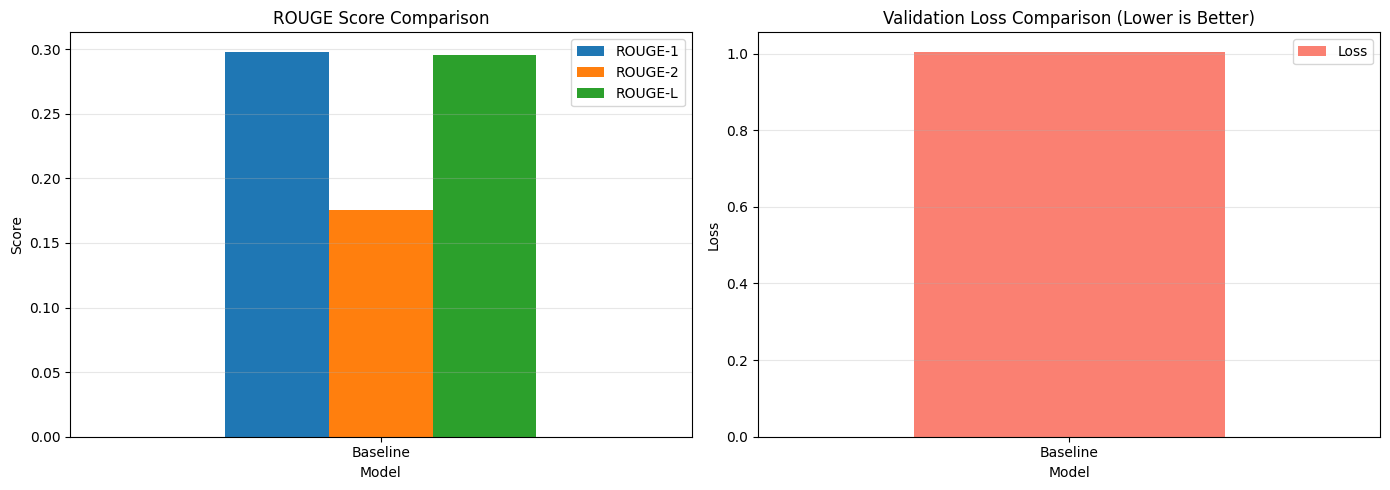

You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.



=== Sample Outputs Comparison ===

[Baseline Prediction]
> Loading Generative Model from /content/drive/MyDrive/data/runs/news_baseline/generative_baseline/checkpoint-12162...


,Input (Truncated),Target,Prediction
0,"[1] 취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고, 처분...","취소소송은 처분 등이 있다는 것을 안 때로부터 90일 이내에 제기하여야 하고, 행정...",취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고 처분 등이 있...
1,[1] 항고소송의 대상이 되는 행정처분이라 함은 원칙적으로 행정청의 공법상 행위로서...,항고소송의 대상이 되는 행정처분이란 일반 국민의 권리의무에 직접 영향을 미치는 행위...,항고소송의 대상이 되는 행정처분이라 함은 원칙적으로 행정청의 공법상 행위로서 특정 ...


You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.



[Hybrid Prediction (Smart Reconstruction)]
> Loading Generative Model from /content/drive/MyDrive/data/runs/news_robust_hybrid/generative_hybrid/checkpoint-1800...
> Loading Extractive Model for hint generation from /content/drive/MyDrive/data/runs/news_robust_hybrid/robust_extractive/checkpoint-1600...


,Input (Truncated),Target,Prediction
0,"[1] 취소소송은 처분 등이 있음을 안 날부터 90일 이내에 제기하여야 하고, 처분...","취소소송은 처분 등이 있다는 것을 안 때로부터 90일 이내에 제기하여야 하고, 행정...","사도개설허가에서 정해진 공사기간 내에 사도로 준공검사를 받지 못한 경우, 이 공사기..."
1,[1] 항고소송의 대상이 되는 행정처분이라 함은 원칙적으로 행정청의 공법상 행위로서...,항고소송의 대상이 되는 행정처분이란 일반 국민의 권리의무에 직접 영향을 미치는 행위...,항고소송의 대상이 되는 행정처분이라 함은 원칙적으로 행정청의 공법상 행위로서 특정 ...


In [84]:
# === 성능 비교, 시각화 및 샘플 생성 (Complete Version) ===
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import BartForConditionalGeneration, PreTrainedTokenizerFast
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch
import numpy as np
import os

# 결과 경로 설정
BASELINE_DIR = Path(EXPERIMENT_DRIVE_ROOT) / "news_baseline" / "generative_baseline"
HYBRID_GEN_DIR = Path(EXPERIMENT_DRIVE_ROOT) / "news_robust_hybrid" / "generative_hybrid"
HYBRID_EXT_DIR = Path(EXPERIMENT_DRIVE_ROOT) / "news_robust_hybrid" / "robust_extractive"

# --- 1. Metrics Loading & Visualization ---
def load_metrics(exp_dir):
    metrics_path = exp_dir / "metrics.csv"
    if metrics_path.exists():
        return pd.read_csv(metrics_path)
    return None

baseline_metrics = load_metrics(BASELINE_DIR)
hybrid_metrics = load_metrics(HYBRID_GEN_DIR)

print("\n=== Performance Comparison (Metrics) ===")
comparison = []
if baseline_metrics is not None and not baseline_metrics.empty:
    latest = baseline_metrics.iloc[-1]
    comparison.append({
        "Model": "Baseline",
        "ROUGE-1": latest.get("eval_rough1", 0),
        "ROUGE-2": latest.get("eval_rouge2", 0),
        "ROUGE-L": latest.get("eval_rougeL", 0),
        "Loss": latest.get("eval_loss", 0)
    })

if hybrid_metrics is not None and not hybrid_metrics.empty:
    latest = hybrid_metrics.iloc[-1]
    comparison.append({
        "Model": "Robust Hybrid",
        "ROUGE-1": latest.get("eval_rough1", 0),
        "ROUGE-2": latest.get("eval_rouge2", 0),
        "ROUGE-L": latest.get("eval_rougeL", 0),
        "Loss": latest.get("eval_loss", 0)
    })

if comparison:
    df_comp = pd.DataFrame(comparison)
    display(df_comp)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df_comp.plot(x="Model", y=["ROUGE-1", "ROUGE-2", "ROUGE-L"], kind="bar", ax=axes[0], rot=0)
    axes[0].set_title("ROUGE Score Comparison")
    axes[0].set_ylabel("Score")
    axes[0].grid(axis='y', alpha=0.3)

    df_comp.plot(x="Model", y="Loss", kind="bar", ax=axes[1], color="salmon", rot=0)
    axes[1].set_title("Validation Loss Comparison (Lower is Better)")
    axes[1].set_ylabel("Loss")
    axes[1].grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No metrics found to compare.")

# --- Helper: Find Latest Checkpoint ---
def find_latest_ckpt(ckpt_dir: Path):
    if not ckpt_dir.exists(): return None
    checkpoints = sorted(
        ckpt_dir.glob("checkpoint-*"),
        key=lambda p: int(p.name.split("-")[-1]) if p.name.split("-")[-1].isdigit() else -1,
    )
    return str(checkpoints[-1]) if checkpoints else None

# --- 2. On-the-fly Extractor (To fix the warning) ---
class InstantExtractor:
    def __init__(self, ckpt_path):
        print(f"> Loading Extractive Model for hint generation from {ckpt_path}...")
        self.model = AutoModelForSequenceClassification.from_pretrained(ckpt_path)
        self.tokenizer = AutoTokenizer.from_pretrained(ckpt_path)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.model.eval()

    def extract(self, sentences, top_k=3):
        if not sentences: return ""
        # Prepare inputs
        inputs = self.tokenizer(sentences, return_tensors="pt", padding=True, truncation=True, max_length=256)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs)
            scores = outputs.logits[:, 1] # Positive class score

        # Select top-k
        scores = scores.cpu().numpy()
        top_indices = scores.argsort()[-top_k:][::-1]
        top_indices.sort() # Keep original order

        selected_sents = [sentences[i] for i in top_indices]
        return " ".join(selected_sents)

# --- 3. Sample Generation ---
def generate_samples_robust(model_dir: Path, dataset_split, ext_model_dir=None, num_samples=2):
    ckpt_path = find_latest_ckpt(model_dir)
    if not ckpt_path:
        print(f"No generation checkpoint found in {model_dir}")
        return None

    print(f"> Loading Generative Model from {ckpt_path}...")
    gen_model = BartForConditionalGeneration.from_pretrained(ckpt_path)
    gen_tokenizer = PreTrainedTokenizerFast.from_pretrained(ckpt_path)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gen_model.to(device)

    # Check if we need (and have) an extractor
    extractor = None
    if ext_model_dir:
        ext_ckpt = find_latest_ckpt(ext_model_dir)
        if ext_ckpt:
            extractor = InstantExtractor(ext_ckpt)
        else:
            print("(Warning: Extractive checkpoint not found. Proceeding without hints.)")

    indices = list(range(min(len(dataset_split), num_samples)))
    samples = dataset_split.select(indices)

    results = []
    for example in samples:
        text = example.get("full_text", "")
        input_text = text

        # Apply Hybrid Logic
        if ext_model_dir:
            if "predicted_extract_summary" in example and example["predicted_extract_summary"]:
                # Use existing hint if available
                hint = example["predicted_extract_summary"]
            elif extractor and "text" in example:
                # Generate hint on the fly!
                hint = extractor.extract(example["text"])
            else:
                hint = ""

            if hint:
                input_text = f"[추출요약] {hint} </s> [본문] {text}"

        inputs = gen_tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            summary_ids = gen_model.generate(inputs["input_ids"], max_length=150, num_beams=4, length_penalty=2.0)

        summary_ids = np.where(summary_ids.cpu().numpy() != -100, summary_ids.cpu().numpy(), gen_tokenizer.pad_token_id)
        pred = gen_tokenizer.decode(summary_ids[0], skip_special_tokens=True)

        results.append({
            "Input (Truncated)": text[:80] + "...",
            "Target": example["target"],
            "Prediction": pred
        })
    return pd.DataFrame(results)

print("\n=== Sample Outputs Comparison ===")

print("\n[Baseline Prediction]")
df_base = generate_samples_robust(BASELINE_DIR, news_dataset['val'], num_samples=2)
if df_base is not None: display(df_base)

print("\n[Hybrid Prediction (Smart Reconstruction)]")
df_hybrid = generate_samples_robust(HYBRID_GEN_DIR, news_dataset['val'], ext_model_dir=HYBRID_EXT_DIR, num_samples=2)
if df_hybrid is not None: display(df_hybrid)
